#### Imports

In [1]:
# pandas for data manipulation
# re for regular expressions
import importlib
import re

# pyplot for plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# other .py files
from utils import graphs as graphs_module
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info
from utils.graphs import (
    draw_3d_graphs_for_all_files,
    plot_all_packets_vs_subcarrier,
    plot_csi_spectrogram,
    plot_scenario_comparison_vs_subcarrier,
    plot_subcarrier_magnitude_vs_time,
)

# Reload custom plotting module so notebook picks up recent file edits.
importlib.reload(graphs_module)

<module 'utils.graphs' from 'c:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project\\utils\\graphs.py'>

#### Scenarios processing

In [2]:
# Scenario ID decoder
# Example: 21313_A -> "Scen. 2; 5 GHz; Random plac.; 1 m; 3 ESPs; Zone A"

SCENARIO_ID_MAPS = {
    "scenario_number": {
        "1": "Scen. 1",
        "2": "Scen. 2",
        "3": "Scen. 3",
    },
    "frequency_band": {
        "1": "2.4 Ghz",
        "2": "5 Ghz",
        "3": "Mixed freq.",
    },
    "sensor_placement": {
        "1": "Lay Down",
        "2": "Standing",
        "3": "Random plac.",
    },
    "height": {
        "0": "floor",
        "1": "1 m",
        "2": "2 m",
        "3": "Random height",
    },
    "esp_count": {
        "1": "1 ESP",
        "2": "2 ESPs",
        "3": "3 ESPs",
        "4": "4 ESPs",
        "5": "5 ESPs",
    },
}


def decode_scenario_id(scenario_id: str | int) -> dict[str, str]:
    scenario_str = str(scenario_id)

    if scenario_str.startswith("scenario_"):
        scenario_str = scenario_str.split("_", 1)[1]

    parts = scenario_str.split("_", 1)
    base_scenario = parts[0]
    zone = parts[1].upper() if len(parts) > 1 else ""

    if len(base_scenario) != 5 or not base_scenario.isdigit():
        raise ValueError(
            f"Invalid scenario_id '{scenario_id}'. Expected 5 digits with optional zone suffix, e.g. '21313_A'."
        )

    d1, d2, d3, d4, d5 = base_scenario

    return {
        "scenario_id": scenario_str,
        "base_scenario_id": base_scenario,
        "zone": zone,
        "scenario_number": SCENARIO_ID_MAPS["scenario_number"].get(d1, f"Unknown ({d1})"),
        "frequency_band": SCENARIO_ID_MAPS["frequency_band"].get(d2, f"Unknown ({d2})"),
        "sensor_placement": SCENARIO_ID_MAPS["sensor_placement"].get(d3, f"Unknown ({d3})"),
        "height": SCENARIO_ID_MAPS["height"].get(d4, f"Unknown ({d4})"),
        "esp_count": SCENARIO_ID_MAPS["esp_count"].get(d5, f"Unknown ({d5})"),
    }


def scenario_id_to_label(scenario_id: str | int) -> str:
    decoded = decode_scenario_id(scenario_id)
    parts = [
        decoded["scenario_number"],
        decoded["frequency_band"],
        decoded["sensor_placement"],
        decoded["height"],
        decoded["esp_count"],
    ]
    if decoded["zone"]:
        parts.append(f"Zone {decoded['zone']}")

    return "; ".join(parts)


def normalize_scenario_id(value: str) -> str:
    value_str = str(value).strip()
    if value_str.startswith("scenario_"):
        return value_str

    parts = value_str.split("_", 1)
    if len(parts) == 1 and len(value_str) == 5 and value_str.isdigit():
        return f"scenario_{value_str}"

    if len(parts) == 2 and len(parts[0]) == 5 and parts[0].isdigit() and parts[1].isalpha():
        return f"scenario_{parts[0]}_{parts[1].upper()}"

    return value_str


def resolve_selected_scenarios(
    selected: list[str] | None,
    available_ids: list[str],
) -> tuple[set[str], list[str]]:
    if not selected:
        return set(available_ids), []

    available_set = set(available_ids)
    resolved: set[str] = set()
    unresolved: list[str] = []

    label_to_id = {scenario_id_to_label(sid): sid for sid in available_ids}

    for item in selected:
        candidate = normalize_scenario_id(item)
        if candidate in available_set:
            resolved.add(candidate)
            continue

        if item in label_to_id:
            resolved.add(label_to_id[item])
            continue

        unresolved.append(item)

    return resolved, unresolved

##### Scenario selection

In [3]:
# Retrieve CSV files and apply a global scenario filter early in the pipeline.

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data\\zones"

# scenario -> user -> activity -> esp -> trial -> file_path
FileMap = dict[str, dict[str, dict[str, dict[str, dict[str, str]]]]]
# scenario -> user -> activity -> esp -> trial -> csi ndarray
csi_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]

data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id, trials_id, zones_id = sort_meta_info(path)

available_scenarios = sorted(normalize_scenario_id(scenario) for scenario in scenarios_id)

print(f"Scenarios found in files ({len(available_scenarios)}):")
for scenario_id in available_scenarios:
    print(f"  - {scenario_id}: {scenario_id_to_label(scenario_id)}")

# Single source of truth: define selected scenarios here.
# Use None or [] to process all available scenarios.
selected_scenarios: list[str] | None = [
    "22212_AB",

]

selected_scenario_ids, unresolved_scenarios = resolve_selected_scenarios(
    selected_scenarios,
    available_scenarios,
)

if unresolved_scenarios:
    print("[WARN] Some selected scenarios were not found and will be ignored:")
    print(unresolved_scenarios)

# Keep only selected scenarios so ALL downstream processing is restricted.
data_files = {
    scenario_key: scenario_map
    for scenario_key, scenario_map in data_files.items()
    if normalize_scenario_id(scenario_key) in selected_scenario_ids
}

scenarios_id = sorted(selected_scenario_ids)

print(f"\nScenarios (selected): {scenarios_id}")
print("\nSelected data files: ", data_files)


Scenarios found in files (15):
  - scenario_22211_A: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone A
  - scenario_22211_B: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone B
  - scenario_22211_C: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone C
  - scenario_22211_D: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone D
  - scenario_22211_E: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone E
  - scenario_22212_AB: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB
  - scenario_22212_AC: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AC
  - scenario_22212_AD: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AD
  - scenario_22212_AE: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AE
  - scenario_22212_BC: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone BC
  - scenario_22212_BD: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone BD
  - scenario_22212_BE: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone BE
  - scenario_22212_CD: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone CD
  - scenario_22212_CE: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone CE
  - 

#### Processing functions

In [4]:
def process_csi(data_file: str, its5ghz: bool) -> tuple[np.ndarray, int, int, int]:
    file_csv = pd.read_csv(data_file, header=None)
    acg_gain: float = 0

    # number of samples
    if its5ghz:
        print("\tCom 5 GHz")
        csi_raw: pd.Series = file_csv.iloc[:, 14]
        acg_gain = file_csv.iloc[0, 7]
    else:
        csi_raw: pd.Series = file_csv.iloc[:, 25]

    total_sc_2_4: int = 128
    total_sc_5: int = 106
    valid_csi: list[list[float]] = []

    # contar CSI invÃ¡lidos
    no_match_count: int = 0
    no_complete_count: int = 0

    for entry in csi_raw:
        match = re.search(r"\[(.*?)\]", str(entry))
        if not match:
            no_match_count += 1
            continue

        nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

        if (its5ghz and len(nums) == total_sc_5) or (not its5ghz and len(nums) == total_sc_2_4):
            valid_csi.append(nums)
        else:
            no_complete_count += 1

    valid_csi = np.array(valid_csi)

    print(f"\tTotal CSI entries: {len(csi_raw)}")
    print(f"\tValid CSI entries: {len(valid_csi)}")
    print(f"\tInvalid CSI entries (no match): {no_match_count}")
    print(f"\tInvalid CSI entries (incomplete): {no_complete_count}")
    print(f"\tValid CSI shape: {valid_csi.shape}\n")

    if not its5ghz:
        # (n_amostras, n_subcarriers)
        complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

        # coloca sc DC no centro (index 32)
        fft_csi = np.fft.fftshift(complex_csi, axes=1)

        # Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
        # (n_amostras, 52)
        active_sc = fft_csi[:, 6:58]

        # Remove subcarriers at positions 25, 26, 27 (center)
        # (n_amostras, 49)
        active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

        # seleciona sub_carriers: 2 a 47
        active_sc = active_sc[:, 2:48]
        active_sc = np.abs(active_sc)
    else:
        imag = valid_csi[:, ::2]
        real = valid_csi[:, 1::2]
        complex_csi = real + 1j * imag
        complex_csi = np.delete(complex_csi, [26, 27], axis=1)
        active_sc = np.abs(complex_csi)

    return active_sc, no_match_count, no_complete_count, len(csi_raw)


def process_magnitude(data_files: FileMap) -> csi_map:
    magnitudes = {}
    no_match_count: int = 0
    no_complete_count: int = 0
    total_entries: int = 0

    for scenario_key, users_map in data_files.items():
        print(f"Processing scenario: {scenario_key}")
        magnitudes[scenario_key] = {}

        for user_key, activities_map in users_map.items():
            magnitudes[scenario_key][user_key] = {}

            for activity_key, esps_map in activities_map.items():
                magnitudes[scenario_key][user_key][activity_key] = {}

                for esp_key, trials_map in esps_map.items():
                    magnitudes[scenario_key][user_key][activity_key][esp_key] = {}
                    its5ghz = (
                        True
                        if "05" in esp_key
                        or "06" in esp_key
                        or "07" in esp_key
                        or "08" in esp_key
                        or "09" in esp_key
                        else False
                    )
                    print("Esp key", esp_key, "5GHz:", its5ghz)

                    for trial_key, file_path in trials_map.items():
                        if file_path is None:
                            continue

                        (
                            magnitudes[scenario_key][user_key][activity_key][esp_key][trial_key],
                            no_match,
                            no_complete,
                            total,
                        ) = process_csi(str(file_path), its5ghz)

                        no_match_count += no_match
                        no_complete_count += no_complete
                        total_entries += total

        print(f"Total invalid CSI entries (no match): {no_match_count}")
        print(f"Total invalid CSI entries (incomplete): {no_complete_count}")
        if total_entries > 0:
            print(f"Total percentage of no match: {no_match_count / total_entries:.2%}")
            print(f"Total percentage of incomplete: {no_complete_count / total_entries:.2%}\n\n")
        else:
            print("No entries processed.\n\n")

        no_match_count = 0
        no_complete_count = 0
        total_entries = 0

    return magnitudes

In [5]:
magnitude_data = process_magnitude(data_files)

Processing scenario: scenario_22212_AB
Esp key esp_05 5GHz: True
	Com 5 GHz
	Total CSI entries: 2930
	Valid CSI entries: 2629
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2629, 106)

	Com 5 GHz
	Total CSI entries: 3283
	Valid CSI entries: 2982
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2982, 106)

Esp key esp_08 5GHz: True
	Com 5 GHz
	Total CSI entries: 2875
	Valid CSI entries: 2573
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 302
	Valid CSI shape: (2573, 106)

	Com 5 GHz
	Total CSI entries: 3230
	Valid CSI entries: 2929
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2929, 106)

Esp key esp_05 5GHz: True
	Com 5 GHz
	Total CSI entries: 3091
	Valid CSI entries: 2801
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 290
	Valid CSI shape: (2801, 106)

	Com 5 GHz
	Total CSI entries: 3131
	Valid CSI entrie

## Graph analysis

### 3D Graph

In [6]:
def get_auto_plot_scenarios(magnitude_data: csi_map) -> list[str]:
    if "selected_scenario_ids" in globals() and selected_scenario_ids:
        return sorted(
            scenario_key
            for scenario_key in magnitude_data.keys()
            if scenario_key in selected_scenario_ids
        )
    return sorted(magnitude_data.keys())


def get_available_measurements(
    magnitude_data: csi_map,
    scenario: str,
    preferred_trial: str | None = "trial_01",
) -> list[tuple[str, str, str, str]]:
    selections: list[tuple[str, str, str, str]] = []

    scenario_map = magnitude_data.get(scenario, {})
    for user_key, activities_map in scenario_map.items():
        for activity_key, esps_map in activities_map.items():
            for esp_key, trials_map in esps_map.items():
                trial_items = sorted(trials_map.items())
                if preferred_trial is not None:
                    trial_items = [
                        (trial_key, magnitude)
                        for trial_key, magnitude in trial_items
                        if trial_key == preferred_trial
                    ] or trial_items

                for trial_key, magnitude in trial_items:
                    if magnitude is None or magnitude.size == 0:
                        continue
                    selections.append((user_key, activity_key, esp_key, trial_key))

    return sorted(selections)


def get_representative_measurement(
    magnitude_data: csi_map,
    scenario: str,
    preferred_trial: str | None = "trial_01",
) -> tuple[str, str, str, str] | None:
    selections = get_available_measurements(
        magnitude_data,
        scenario,
        preferred_trial=preferred_trial,
    )
    return selections[0] if selections else None


Auto-plotting 3D graphs for Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB | preferred_trial=trial_02 | available_series=4 | max_plots=10
Saved plot: images\saved_graphs\3D graph\scenario_22212_AB_user_00_activity_00_esp_05_trial_02_3d.png


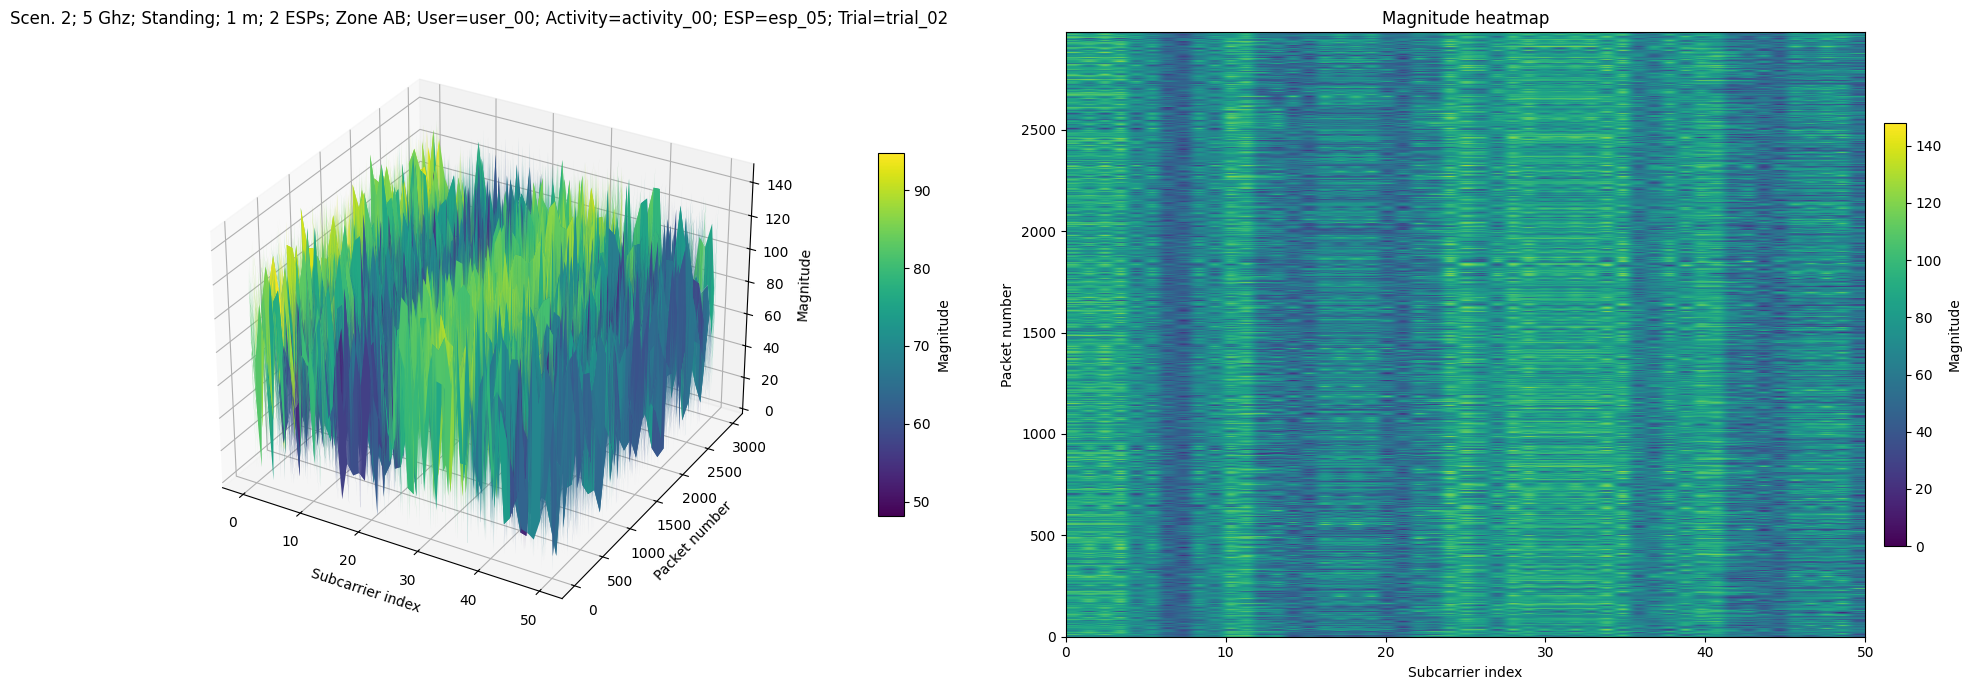

Saved plot: images\saved_graphs\3D graph\scenario_22212_AB_user_00_activity_00_esp_08_trial_02_3d.png


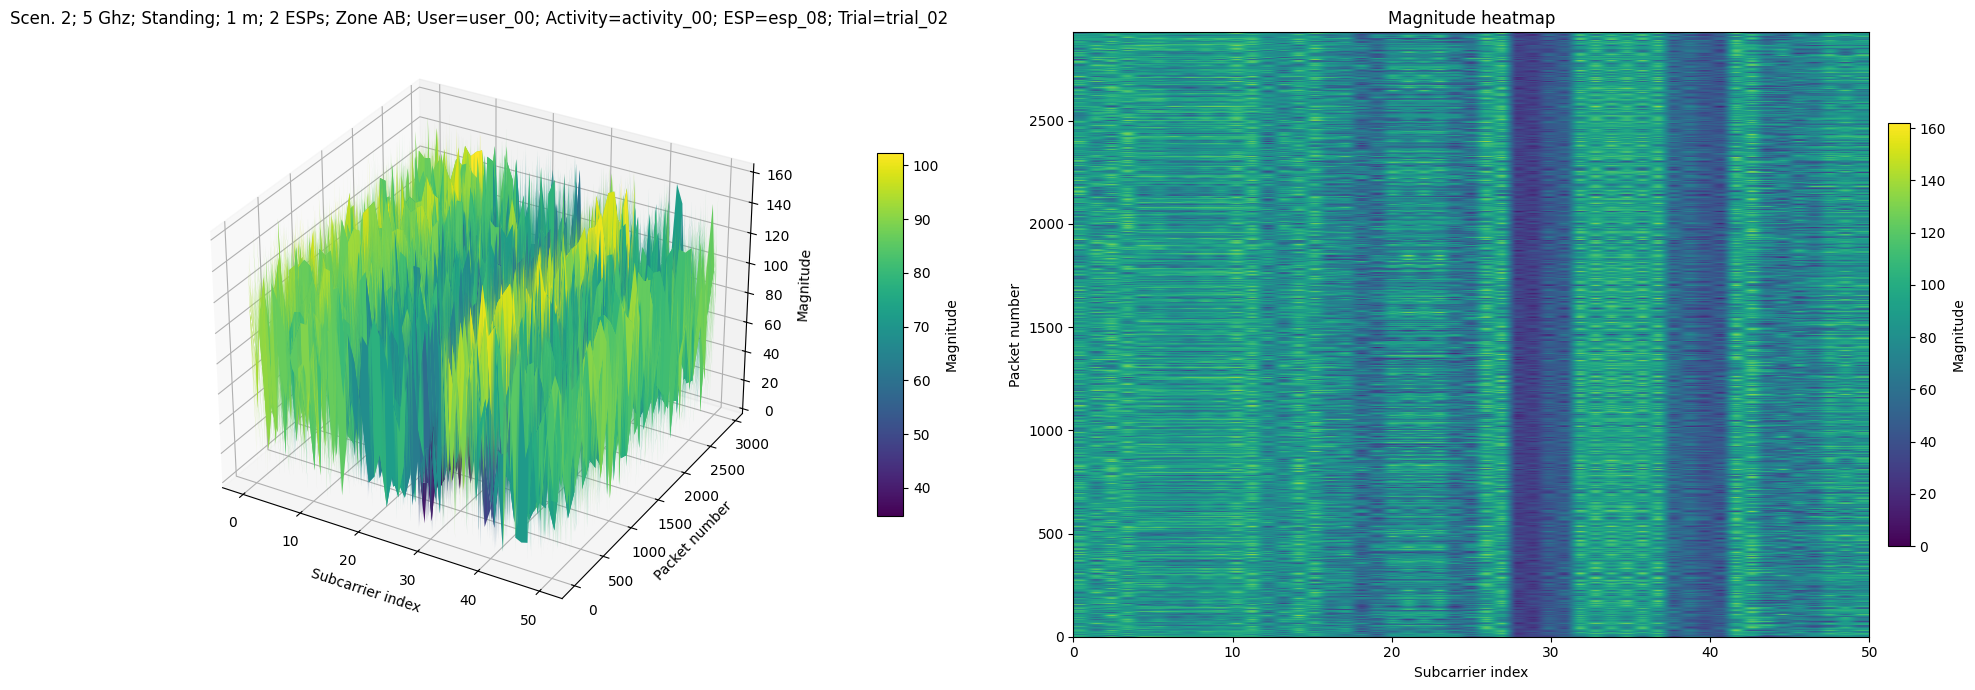

Saved plot: images\saved_graphs\3D graph\scenario_22212_AB_user_01_activity_01_esp_05_trial_02_3d.png


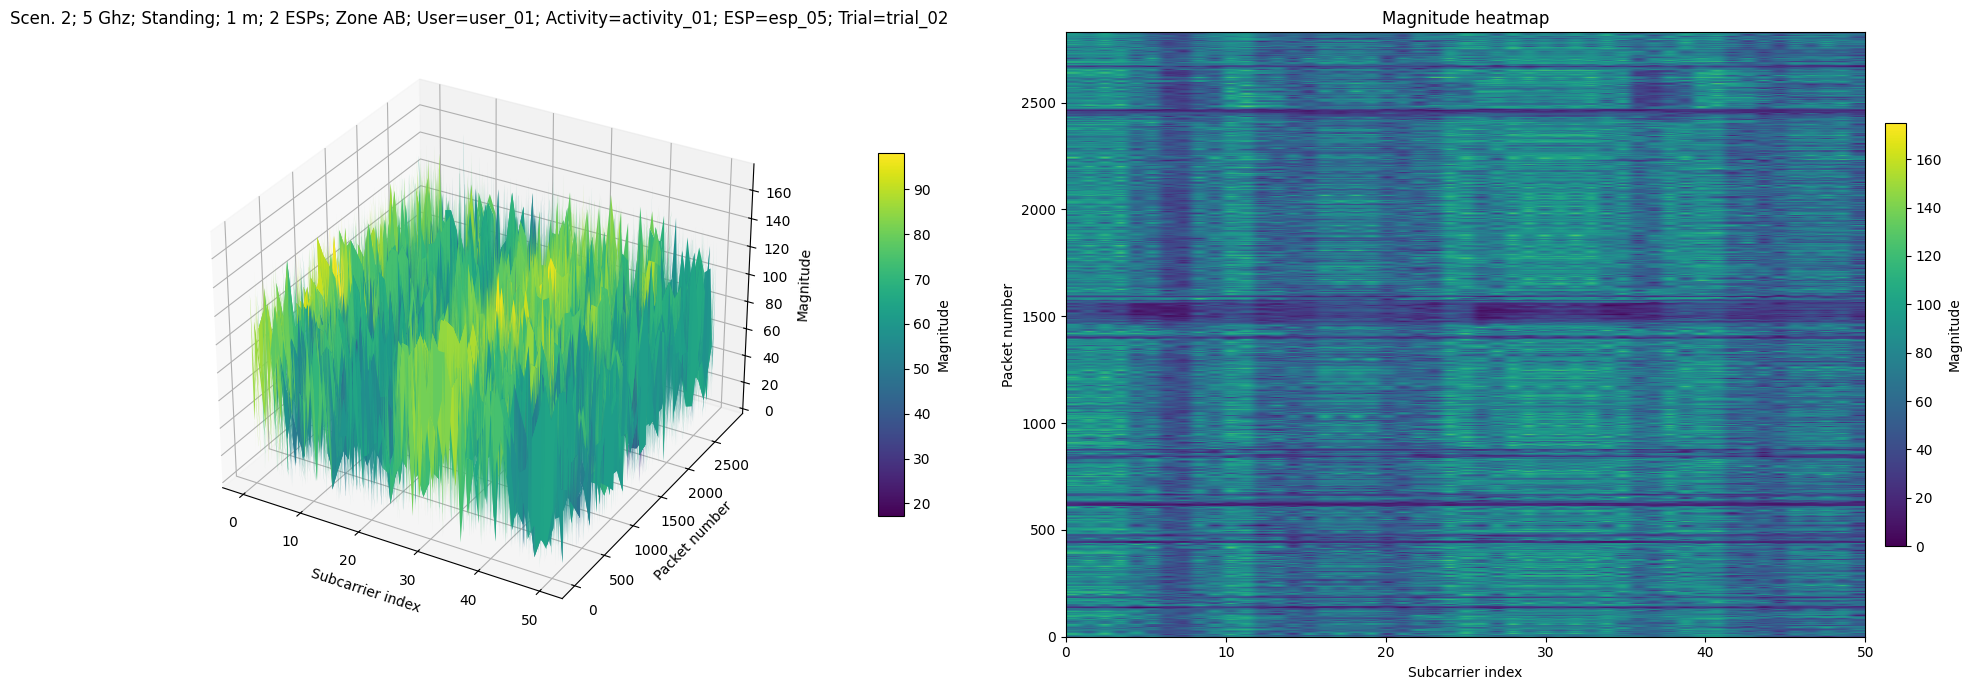

Saved plot: images\saved_graphs\3D graph\scenario_22212_AB_user_01_activity_01_esp_08_trial_02_3d.png


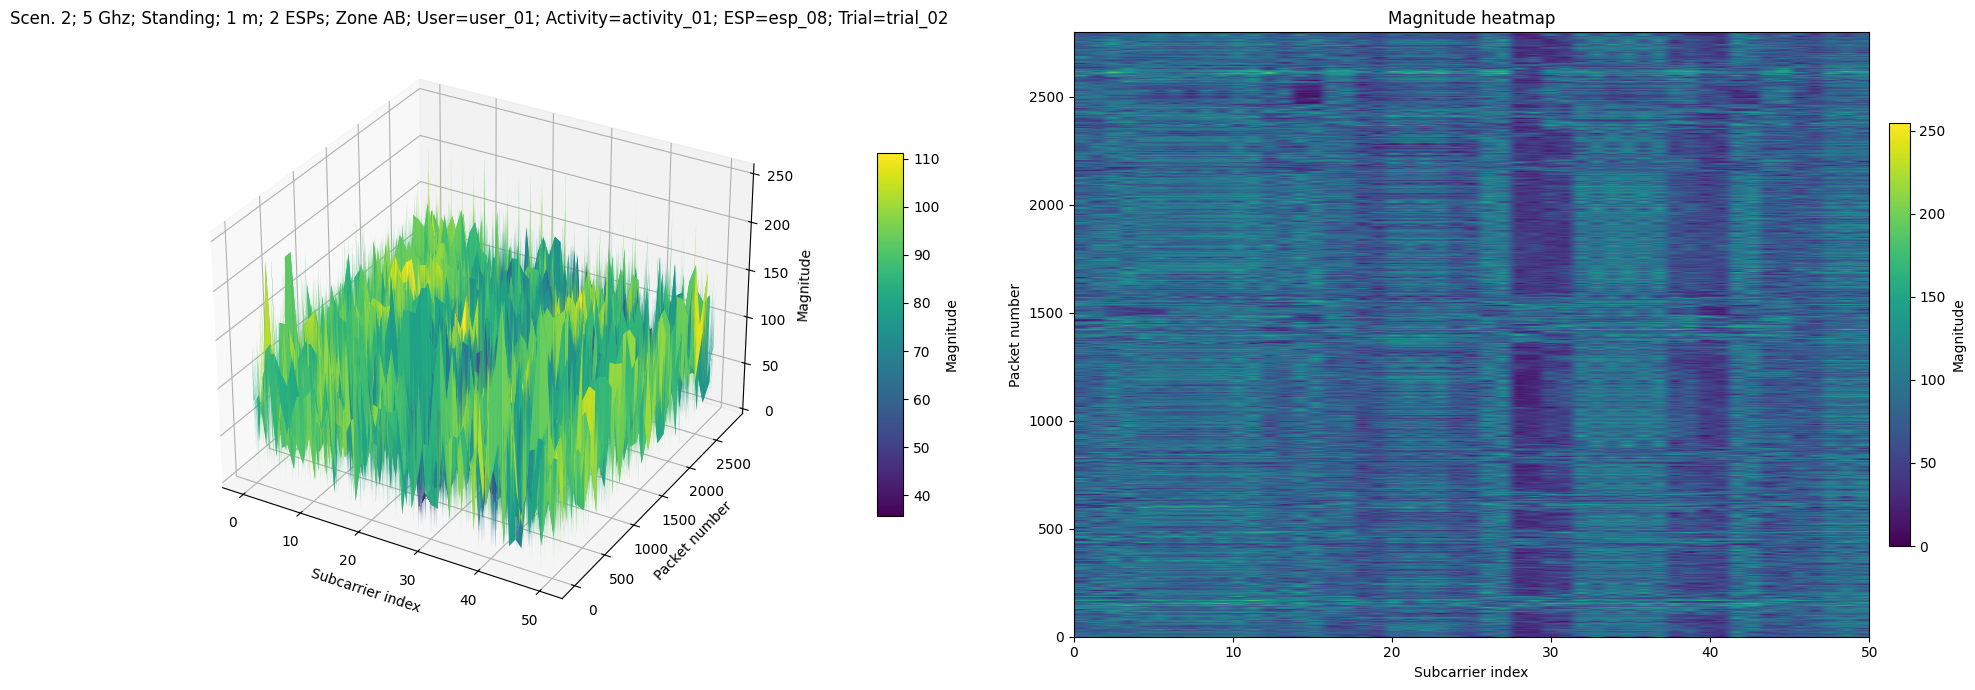

In [7]:
preferred_plot_trial = "trial_02"
max_3d_plots_per_scenario = 10

for scenario_key in get_auto_plot_scenarios(magnitude_data):
    scenario_label = scenario_id_to_label(scenario_key)
    available_count = len(
        get_available_measurements(
            magnitude_data,
            scenario_key,
            preferred_trial=preferred_plot_trial,
        )
    )
    print(
        f"Auto-plotting 3D graphs for {scenario_label} | ",
        f"preferred_trial={preferred_plot_trial} | available_series={available_count} | ",
        f"max_plots={max_3d_plots_per_scenario}",
        sep="",
    )
    draw_3d_graphs_for_all_files(
        magnitude_data,
        scenarios=scenario_key,
        trials=preferred_plot_trial,
        max_plots=max_3d_plots_per_scenario,
    )

### 2D Graph (packet mean)

Auto-plotting scenario comparison for Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB with 4 selected series.
Saved plot: images\saved_graphs\2D graph magnitude comparison\scenario_22212_AB_comparison_mean_4series.png


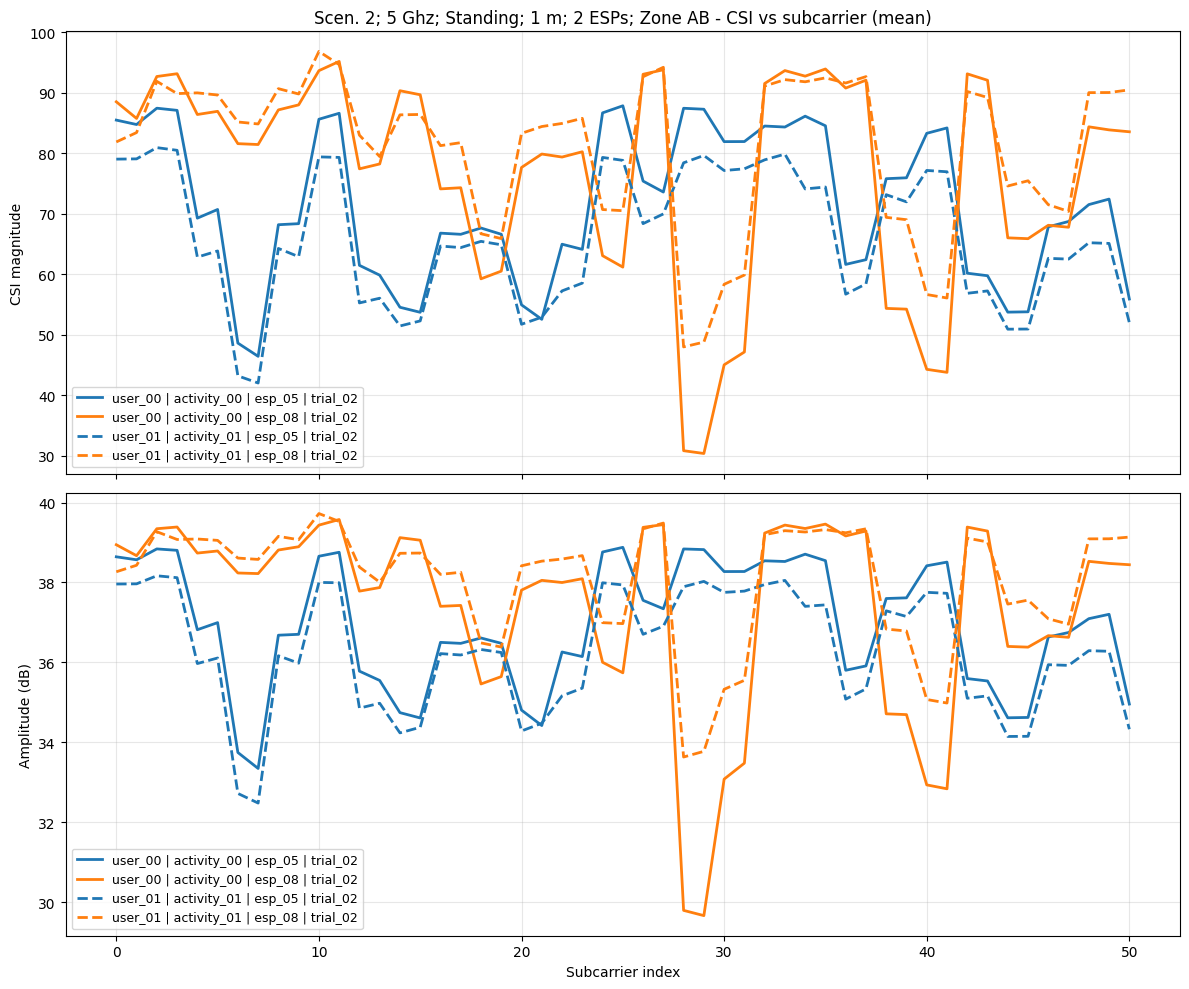

In [8]:
max_comparison_series_per_scenario: int | None = None

for scenario_key in get_auto_plot_scenarios(magnitude_data):
    selections = get_available_measurements(
        magnitude_data,
        scenario_key,
        preferred_trial=preferred_plot_trial,
    )

    if max_comparison_series_per_scenario is not None:
        selections = selections[:max_comparison_series_per_scenario]

    if not selections:
        print(f"[SKIP] No series available for {scenario_id_to_label(scenario_key)}")
        continue

    print(
        f"Auto-plotting scenario comparison for {scenario_id_to_label(scenario_key)} ",
        f"with {len(selections)} selected series.",
        sep="",
    )
    plot_scenario_comparison_vs_subcarrier(
        magnitude_data,
        scenario=scenario_key,
        selections=selections,
        reduction="mean",
        show_db=True,
        db_floor=-120.0,
    )

### 2D Graph (all packets)

Auto-plotting all packets vs subcarrier for Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB | 4 series
  user=user_00, activity=activity_00, esp=esp_05, trial=trial_02
Plotting 597 packets (downsampled from 2982, step=5)
Saved plot: images\saved_graphs\2D graph all packets vs subcarrier\scenario_22212_AB_user_00_activity_00_esp_05_trial_02_all_packets_vs_subcarrier.png


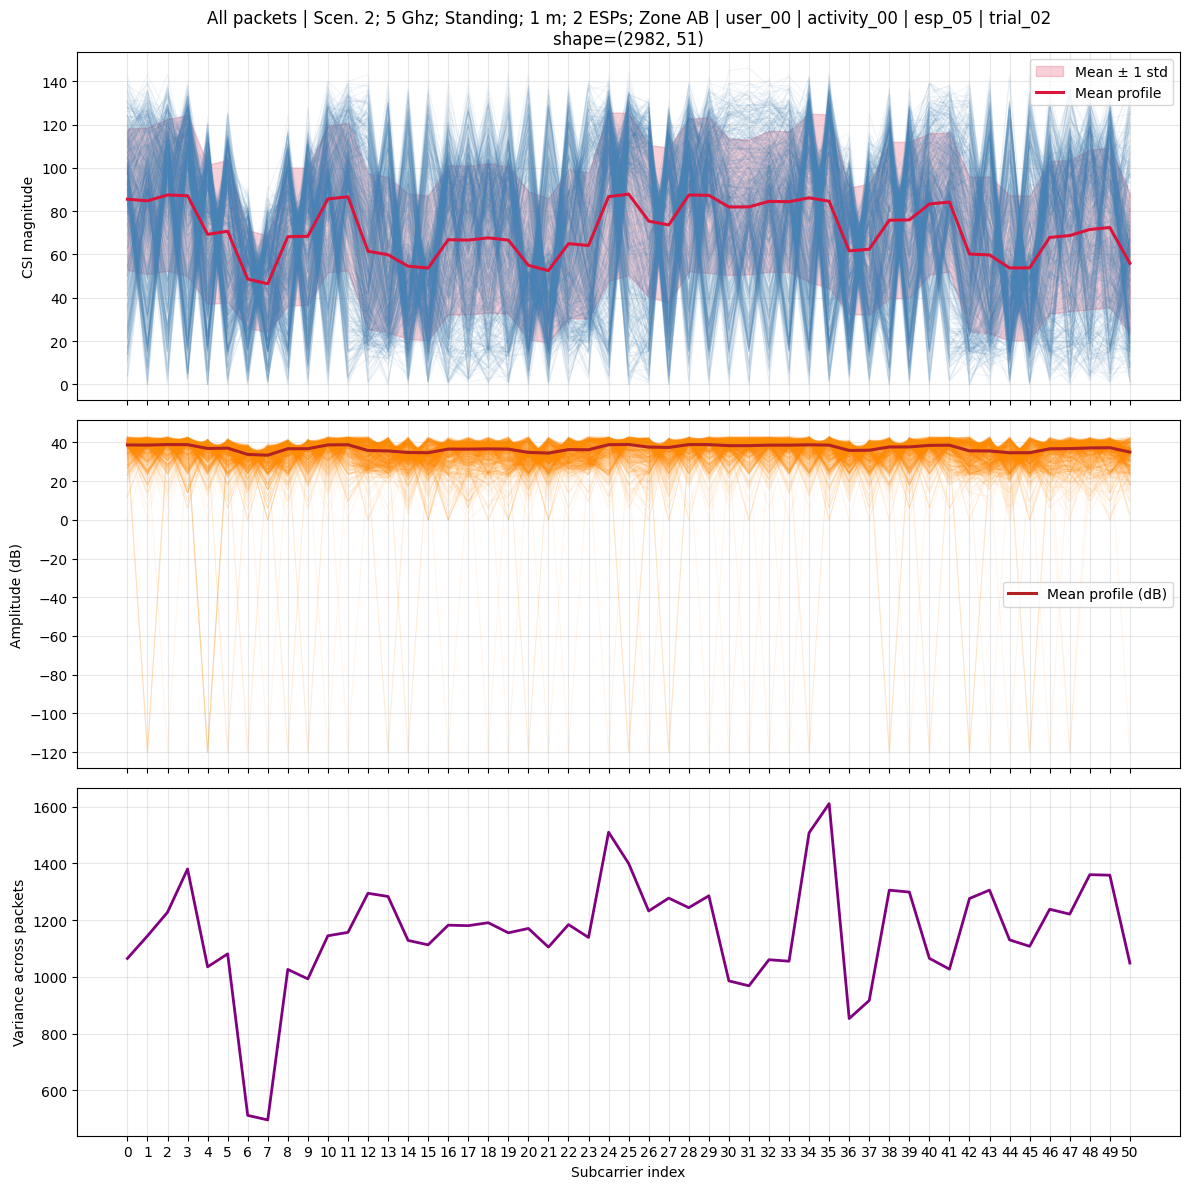

  user=user_00, activity=activity_00, esp=esp_08, trial=trial_02
Plotting 586 packets (downsampled from 2929, step=5)
Saved plot: images\saved_graphs\2D graph all packets vs subcarrier\scenario_22212_AB_user_00_activity_00_esp_08_trial_02_all_packets_vs_subcarrier.png


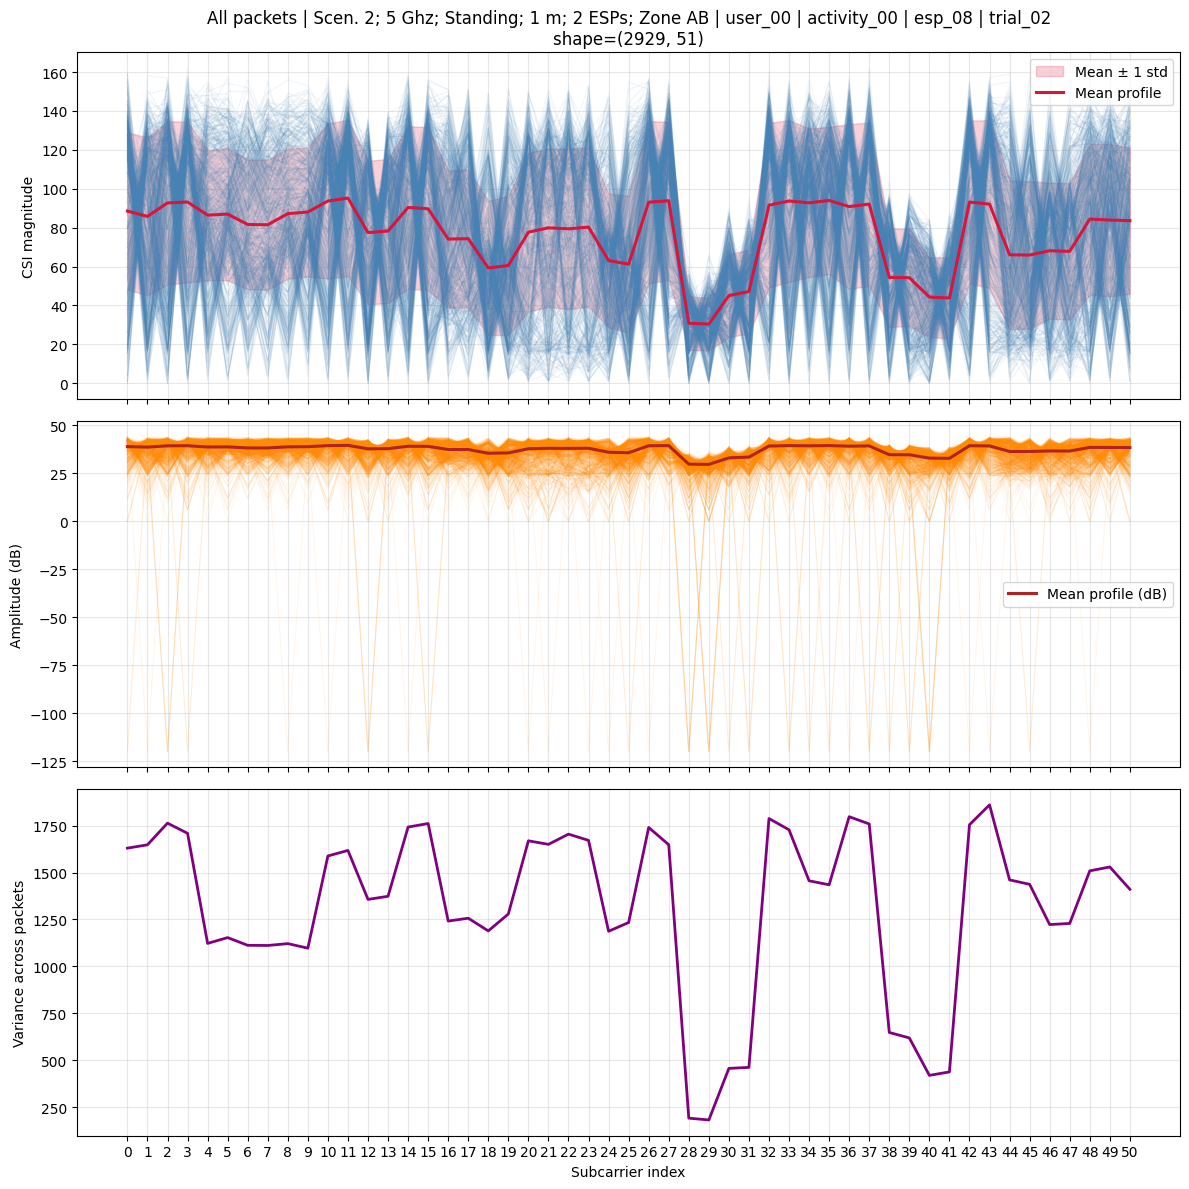

  user=user_01, activity=activity_01, esp=esp_05, trial=trial_02
Plotting 566 packets (downsampled from 2830, step=5)
Saved plot: images\saved_graphs\2D graph all packets vs subcarrier\scenario_22212_AB_user_01_activity_01_esp_05_trial_02_all_packets_vs_subcarrier.png


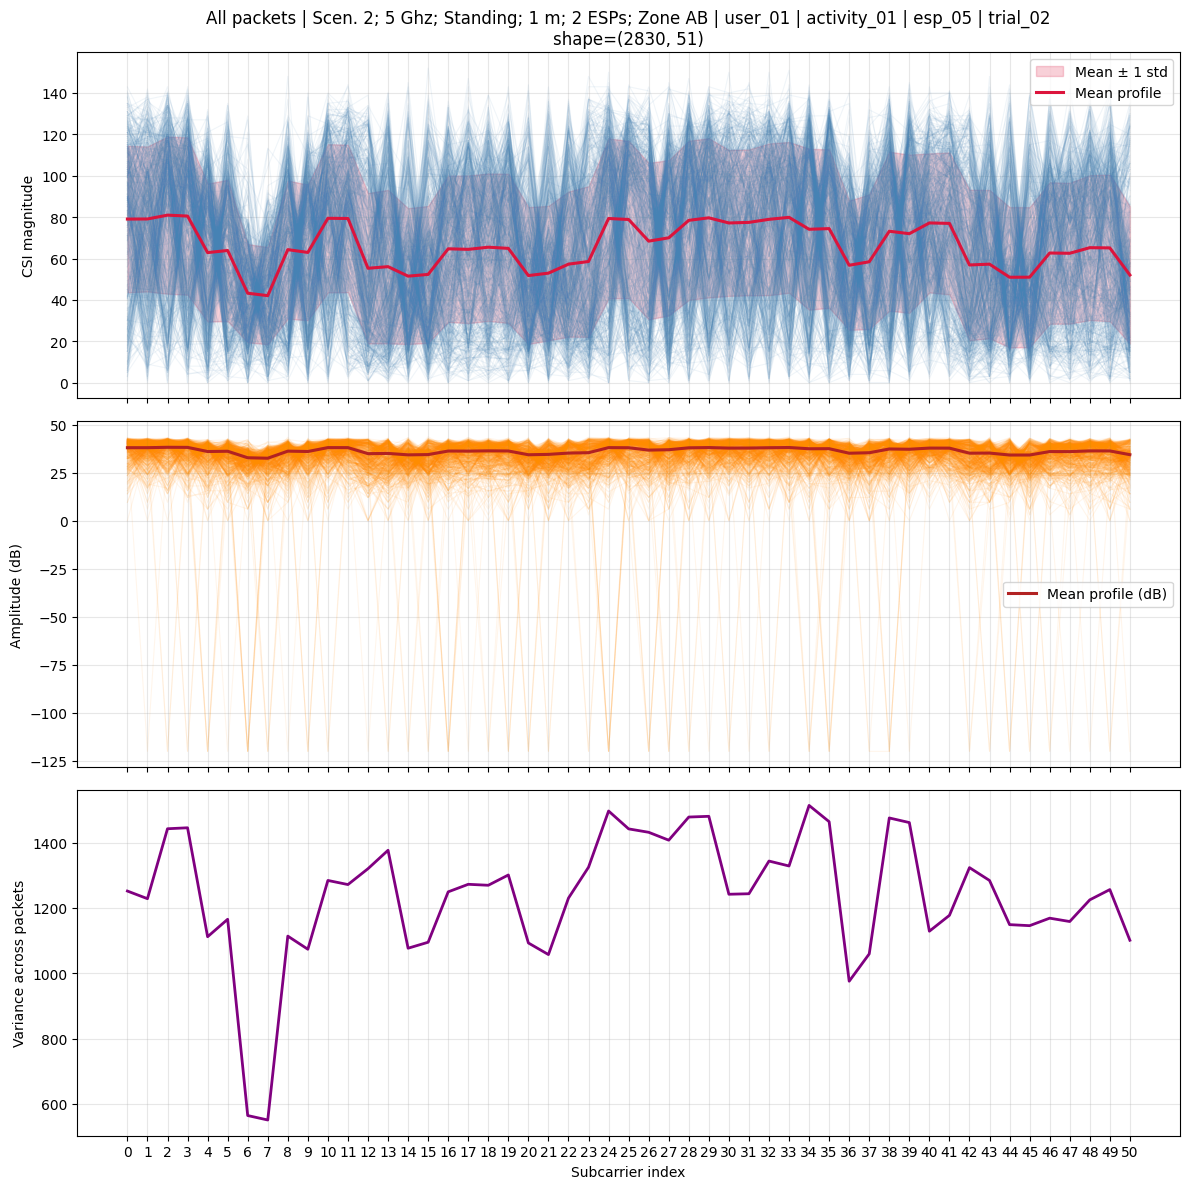

  user=user_01, activity=activity_01, esp=esp_08, trial=trial_02
Plotting 560 packets (downsampled from 2798, step=5)
Saved plot: images\saved_graphs\2D graph all packets vs subcarrier\scenario_22212_AB_user_01_activity_01_esp_08_trial_02_all_packets_vs_subcarrier.png


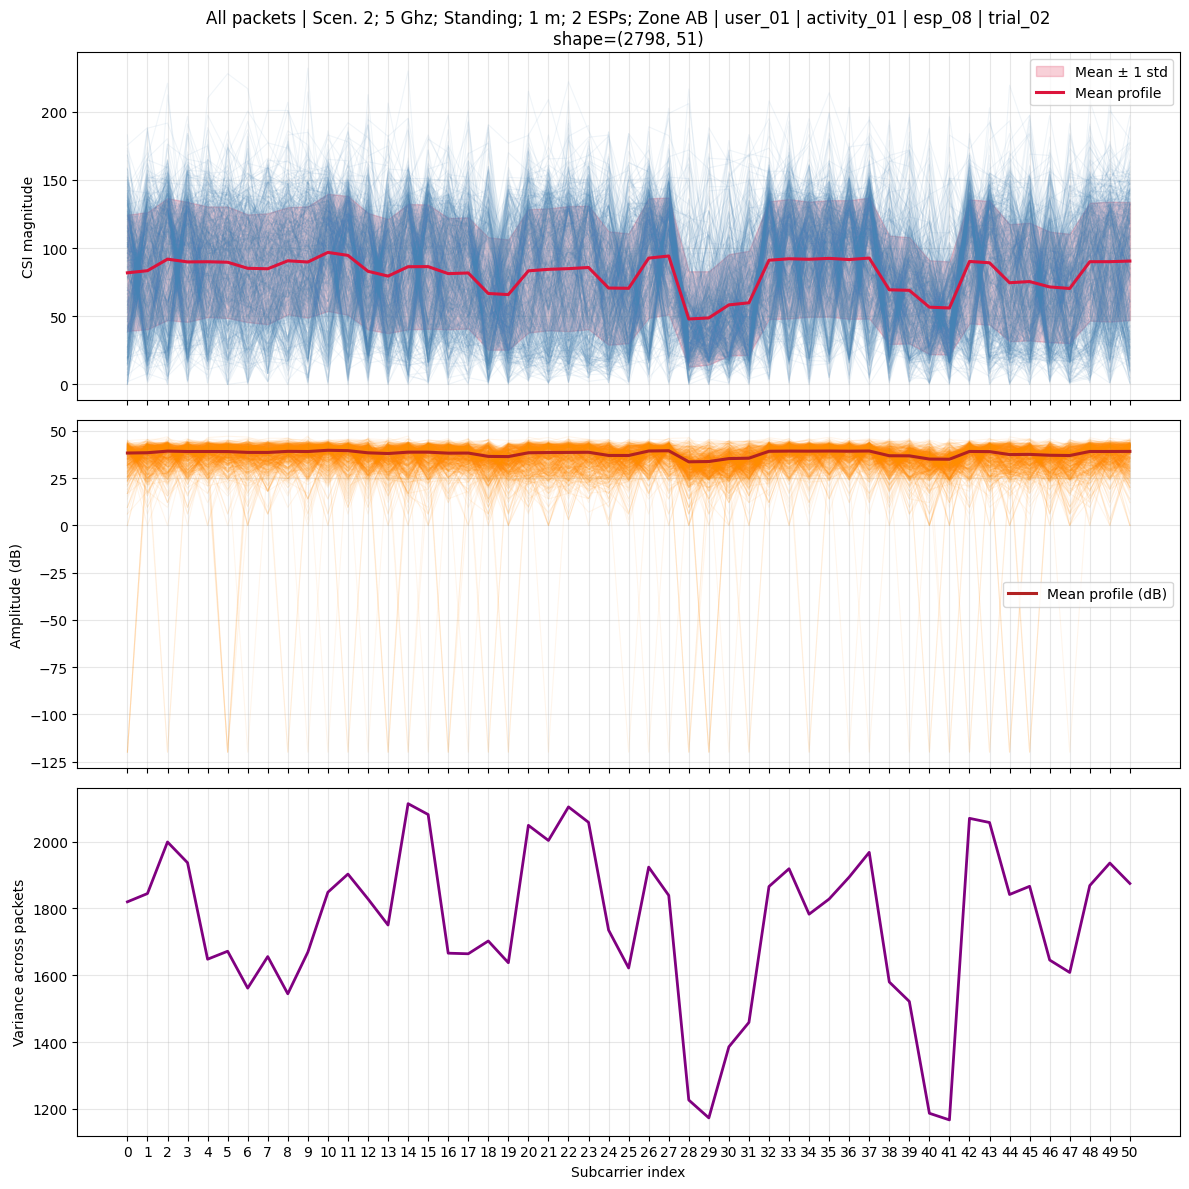

In [9]:
for scenario_key in get_auto_plot_scenarios(magnitude_data):
    selections = get_available_measurements(
        magnitude_data,
        scenario_key,
        preferred_trial=preferred_plot_trial,
    )

    if not selections:
        print(f"[SKIP] No series available for {scenario_id_to_label(scenario_key)}")
        continue

    print(
        f"Auto-plotting all packets vs subcarrier for {scenario_id_to_label(scenario_key)} ",
        f"| {len(selections)} series",
        sep="",
    )

    for user_key, activity_key, esp_key, trial_key in selections:
        print(f"  user={user_key}, activity={activity_key}, esp={esp_key}, trial={trial_key}")
        plot_all_packets_vs_subcarrier(
            magnitude_data,
            scenario=scenario_key,
            user=user_key,
            activity=activity_key,
            esp=esp_key,
            trial=trial_key,
            x_tick_step=1,
            show_db=True,
            db_floor=-120.0,
            max_packets=600,
        )

### 2D Graph (subcarrier selection)

Auto-plotting subcarrier vs time for Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB | user=user_00, activity=activity_00, esp=esp_05, trial=trial_02 | subcarrier=10
Saved plot: images\saved_graphs\2D graph subcarrier vs time\scenario_22212_AB_user_00_activity_00_esp_05_trial_02_subcarrier_10_vs_time.png


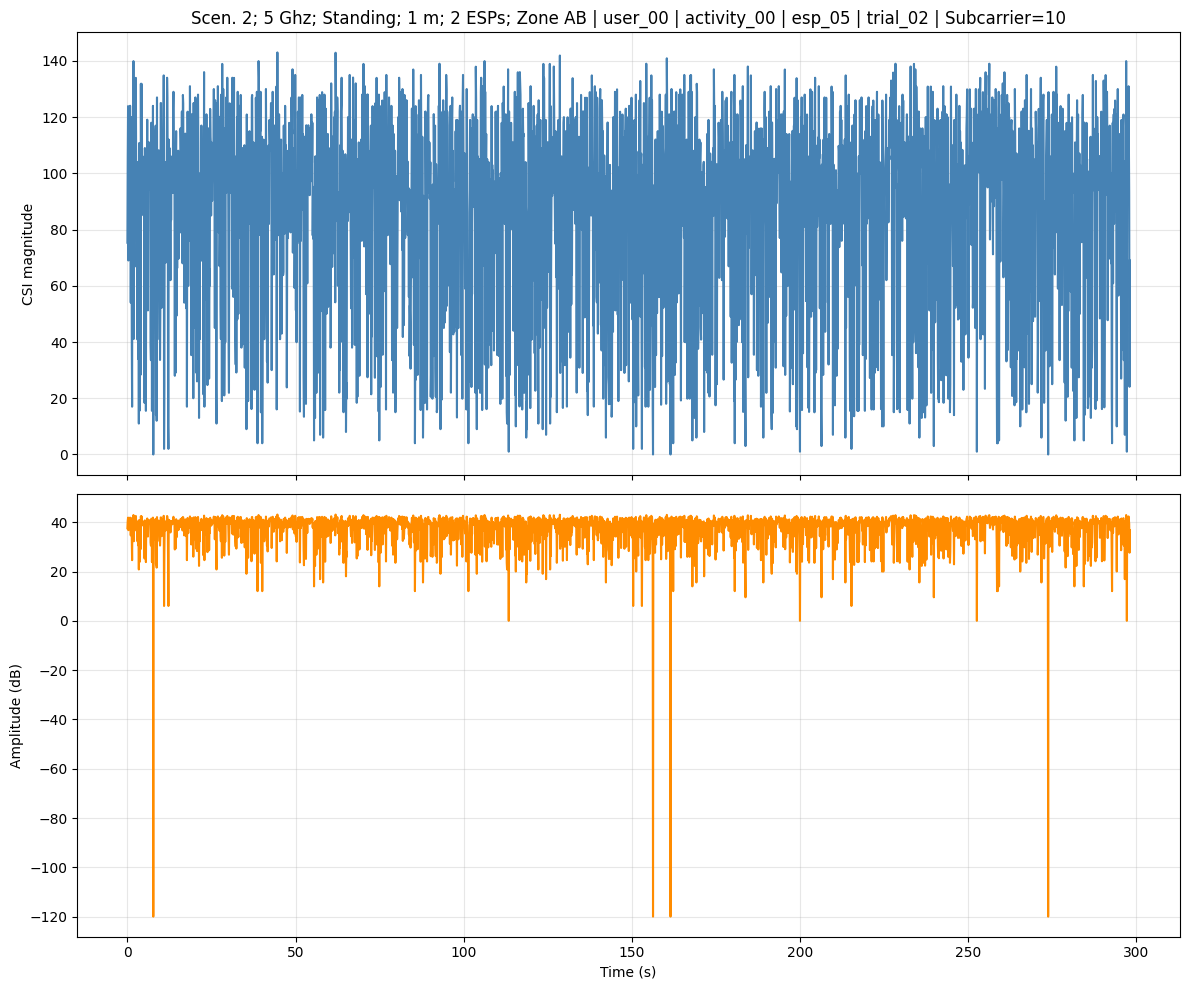

In [10]:
subcarrier_idx_to_plot = 10


for scenario_key in get_auto_plot_scenarios(magnitude_data):
    selection = get_representative_measurement(
        magnitude_data,
        scenario_key,
        preferred_trial=preferred_plot_trial,
    )

    if selection is None:
        print(f"[SKIP] No representative series available for {scenario_id_to_label(scenario_key)}")
        continue

    user_key, activity_key, esp_key, trial_key = selection
    print(
        f"Auto-plotting subcarrier vs time for {scenario_id_to_label(scenario_key)} | ",
        f"user={user_key}, activity={activity_key}, esp={esp_key}, trial={trial_key} | ",
        f"subcarrier={subcarrier_idx_to_plot}",
        sep="",
    )
    plot_subcarrier_magnitude_vs_time(
        magnitude_data,
        scenario=scenario_key,
        user=user_key,
        activity=activity_key,
        esp=esp_key,
        trial=trial_key,
        subcarrier_idx=subcarrier_idx_to_plot,
        sampling_rate_hz=10.0,
        show_db=True,
        db_floor=-120.0,
    )

### 2D Graph (one curve / subcarrier)

Plotting amplitude vs sample for Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB | user=user_00, activity=activity_00, esp=esp_05, trial=trial_02
Plotting all 51 subcarriers.
Legend shortened to 20 subcarriers (out of 51) plus Mean.
Saved plot: images\saved_graphs\2D graph amplitude vs sample\scenario_22212_AB_user_00_activity_00_esp_05_trial_02_all_subcarriers_vs_sample.png


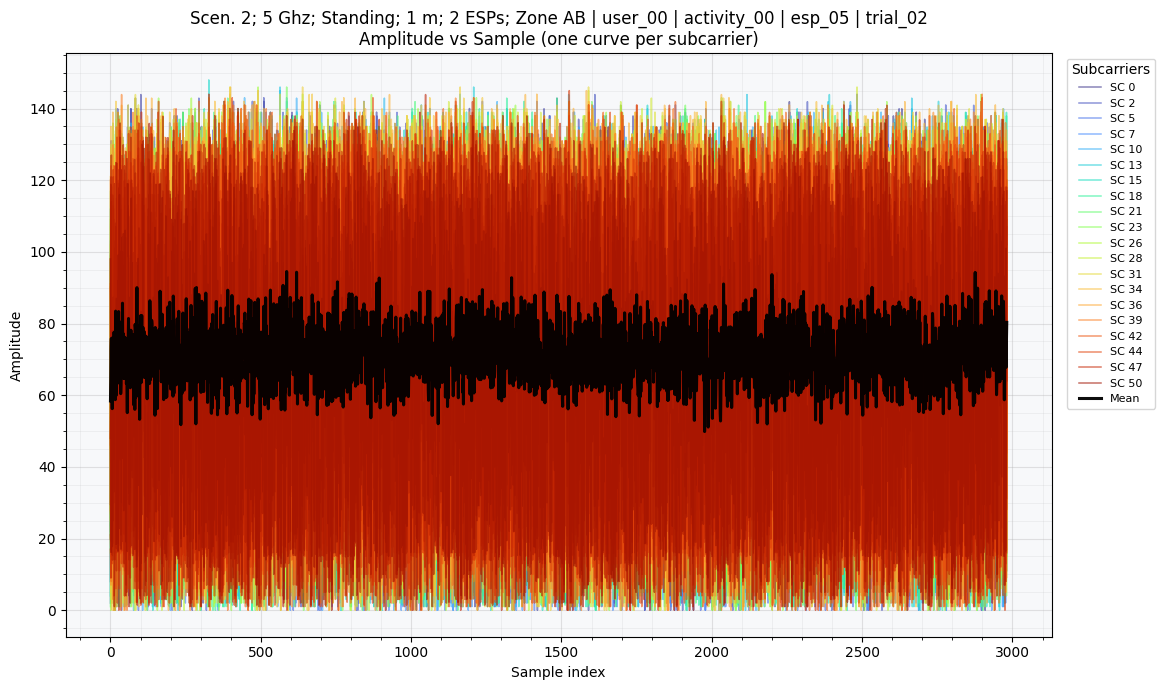

In [11]:
# 2D graph: Amplitude (Oy) vs Sample (Ox), with one curve per subcarrier
importlib.reload(graphs_module)

max_subcarrier_curves: int | None = None  # set e.g. 30 to plot fewer curves

for scenario_key in get_auto_plot_scenarios(magnitude_data):
    selection = get_representative_measurement(
        magnitude_data,
        scenario_key,
        preferred_trial=preferred_plot_trial,
    )

    if selection is None:
        print(f"[SKIP] No representative series available for {scenario_id_to_label(scenario_key)}")
        continue

    user_key, activity_key, esp_key, trial_key = selection
    print(
        f"Plotting amplitude vs sample for {scenario_id_to_label(scenario_key)} | "
        f"user={user_key}, activity={activity_key}, esp={esp_key}, trial={trial_key}"
    )

    graphs_module.plot_subcarrier_amplitude_vs_sample(
        magnitude_data,
        scenario=scenario_key,
        user=user_key,
        activity=activity_key,
        esp=esp_key,
        trial=trial_key,
        max_subcarriers=max_subcarrier_curves,
    )

### Spectrogram

Plotting CSI spectrogram for Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB | user=user_00, activity=activity_00, esp=esp_05, trial=trial_02 | aggregation=pca
Saved plot: images\saved_graphs\spectrogram\scenario_22212_AB_user_00_activity_00_esp_05_trial_02_spectrogram_pca.png


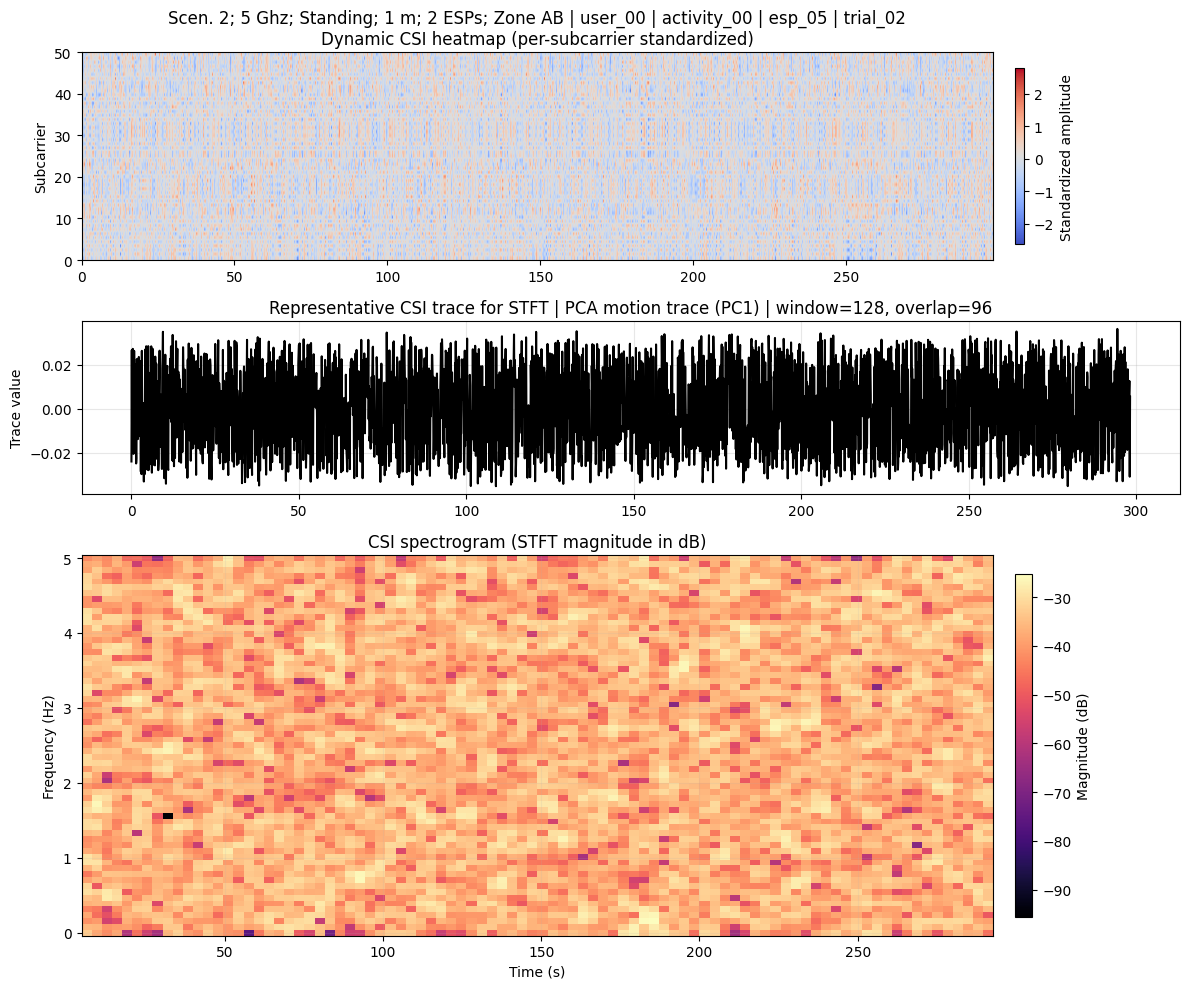

In [12]:
# CSI spectrogram: representative motion trace + STFT
importlib.reload(graphs_module)

spectrogram_sampling_rate_hz = 10.0
spectrogram_window_size = 128
spectrogram_overlap = 96
spectrogram_top_frequency_hz = 5.0
spectrogram_aggregation = "pca"  # options: pca, mean, median, subcarrier
spectrogram_subcarrier_idx: int | None = None

for scenario_key in get_auto_plot_scenarios(magnitude_data):
    selection = get_representative_measurement(
        magnitude_data,
        scenario_key,
        preferred_trial=preferred_plot_trial,
    )

    if selection is None:
        print(f"[SKIP] No representative series available for {scenario_id_to_label(scenario_key)}")
        continue

    user_key, activity_key, esp_key, trial_key = selection
    print(
        f"Plotting CSI spectrogram for {scenario_id_to_label(scenario_key)} | "
        f"user={user_key}, activity={activity_key}, esp={esp_key}, trial={trial_key} | "
        f"aggregation={spectrogram_aggregation}"
    )

    graphs_module.plot_csi_spectrogram(
        magnitude_data,
        scenario=scenario_key,
        user=user_key,
        activity=activity_key,
        esp=esp_key,
        trial=trial_key,
        sampling_rate_hz=spectrogram_sampling_rate_hz,
        aggregation=spectrogram_aggregation,
        subcarrier_idx=spectrogram_subcarrier_idx,
        window_size=spectrogram_window_size,
        overlap=spectrogram_overlap,
        top_frequency_hz=spectrogram_top_frequency_hz,
    )